#### Question : 3 Implement Average Pooling using CUDA.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from numba import cuda

In [4]:
!ls /kaggle/input/datasets/ghnshymsaini/cifar-10-image-dataset/

test  train  trainLabels.csv


In [5]:
DATASET_PATH = "/kaggle/input/datasets/ghnshymsaini/cifar-10-image-dataset/"

train_path = os.path.join(DATASET_PATH, "train", "train")

print("Number of Images:",
      len(os.listdir(train_path)))

Number of Images: 50000


In [6]:
image_file = os.listdir(train_path)[0]

image_path = os.path.join(
    train_path,
    image_file
)

image = Image.open(image_path)
image = np.array(image).astype(np.float32)

print("Shape:", image.shape)

Shape: (32, 32, 3)


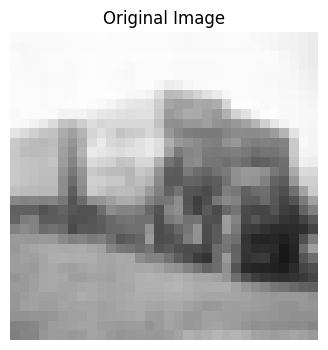

In [7]:
plt.figure(figsize=(4,4))

plt.imshow(image.astype(np.uint8))

plt.title("Original Image")
plt.axis("off")

plt.show()

In [8]:
@cuda.jit
def average_pooling_kernel(input_img,
                           output_img):

    row, col, ch = cuda.grid(3)

    if (row < output_img.shape[0] and
        col < output_img.shape[1] and
        ch < output_img.shape[2]):

        r = row * 2
        c = col * 2

        output_img[row, col, ch] = (
            input_img[r, c, ch] +
            input_img[r+1, c, ch] +
            input_img[r, c+1, ch] +
            input_img[r+1, c+1, ch]
        ) / 4.0

In [9]:
pooled_image = np.zeros(
    (16,16,3),
    dtype=np.float32
)

print("Output Shape:",
      pooled_image.shape)

Output Shape: (16, 16, 3)


In [10]:
d_input = cuda.to_device(image)

d_output = cuda.to_device(
    pooled_image
)

In [11]:
threads_per_block = (8, 8, 3)

blocks_per_grid_x = (
    pooled_image.shape[0] +
    threads_per_block[0] - 1
) // threads_per_block[0]

blocks_per_grid_y = (
    pooled_image.shape[1] +
    threads_per_block[1] - 1
) // threads_per_block[1]

blocks_per_grid = (
    blocks_per_grid_x,
    blocks_per_grid_y,
    1
)

print(blocks_per_grid)

(2, 2, 1)


In [12]:
average_pooling_kernel[
    blocks_per_grid,
    threads_per_block
](
    d_input,
    d_output
)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [13]:
pooled_image = d_output.copy_to_host()

print("Pooled Shape:",
      pooled_image.shape)

Pooled Shape: (16, 16, 3)


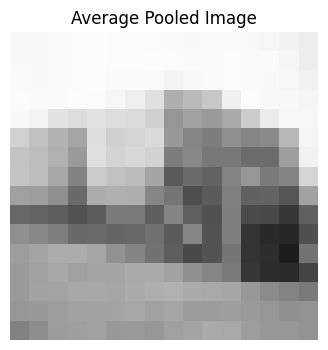

In [14]:
plt.figure(figsize=(4,4))

plt.imshow(
    pooled_image.astype(np.uint8)
)

plt.title("Average Pooled Image")
plt.axis("off")

plt.show()

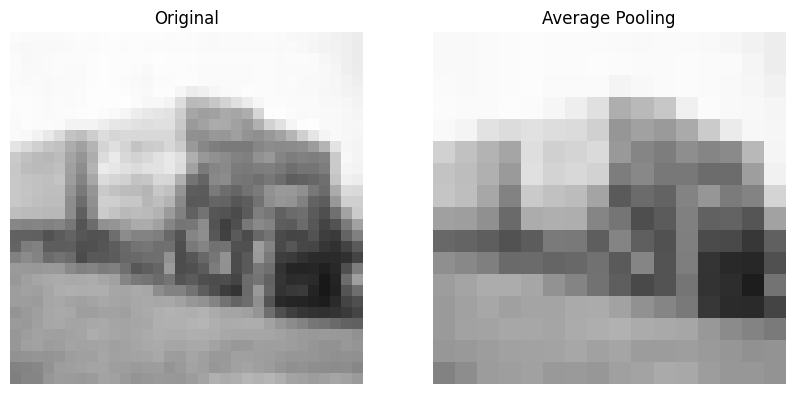

In [15]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image.astype(np.uint8))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(
    pooled_image.astype(np.uint8)
)
plt.title("Average Pooling")
plt.axis("off")

plt.show()

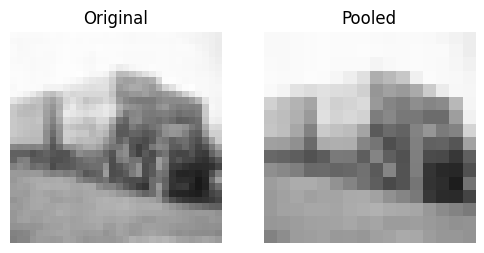

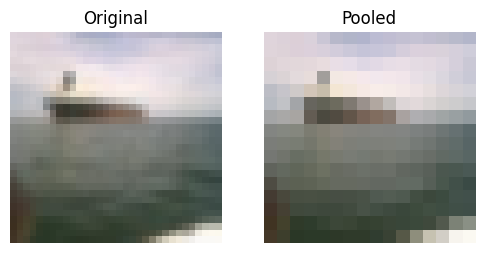

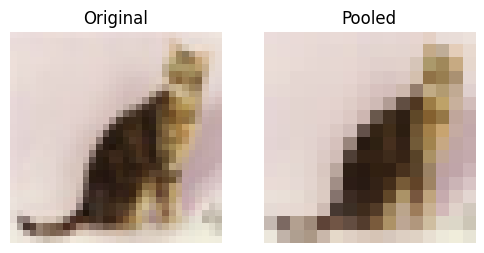

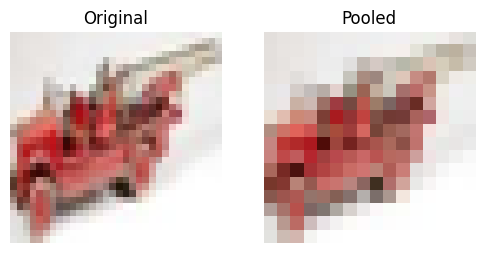

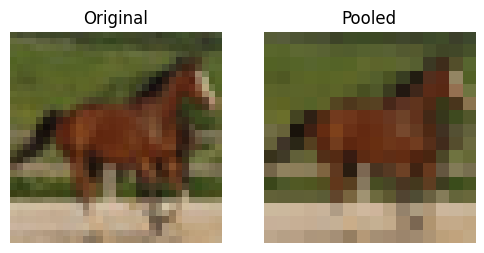

In [16]:
for img_file in os.listdir(train_path)[:5]:

    image_path = os.path.join(
        train_path,
        img_file
    )

    image = np.array(
        Image.open(image_path)
    ).astype(np.float32)

    pooled = np.zeros(
        (16,16,3),
        dtype=np.float32
    )

    d_input = cuda.to_device(image)
    d_output = cuda.to_device(pooled)

    average_pooling_kernel[
        blocks_per_grid,
        threads_per_block
    ](
        d_input,
        d_output
    )

    pooled = d_output.copy_to_host()

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(image.astype(np.uint8))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pooled.astype(np.uint8))
    plt.title("Pooled")
    plt.axis("off")

    plt.show()